In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import replace

from src.config import SimulationConfig
from src.simulator import run_simulation

In [2]:
base_config = SimulationConfig(
    nx=96,
    ny=96,
    voltage=1.0,

    tolerance=1e-5,
    max_iterations=50_000,

    eta=1.0,

    max_steps=5000,
    random_seed=42,
)

In [3]:
etas = [0.5, 1.0, 2.0]

In [4]:
results = {}

for eta in etas:
    config = replace(
        base_config,
        eta=eta
    )

    field, history, breakdown = run_simulation(config)

    results[eta] = {
        "channel": field.channel.copy(),
        "steps": len(history),
        "breakdown": breakdown,
    }

    print(
        f"eta={eta}: "
        f"steps={len(history)}, "
        f"breakdown={breakdown}"
    )

eta=0.5: steps=2554, breakdown=True
eta=1.0: steps=1186, breakdown=True
eta=2.0: steps=448, breakdown=True


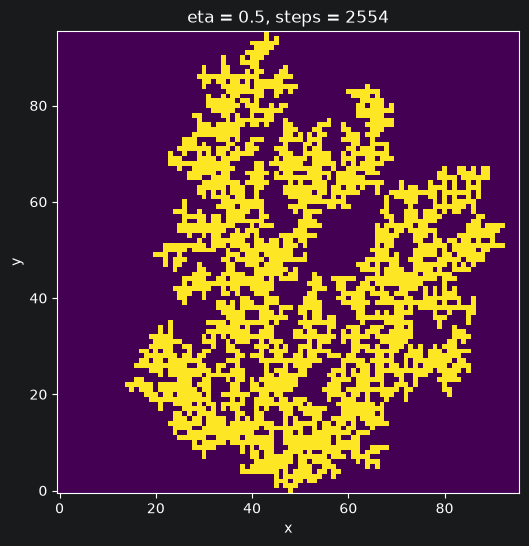

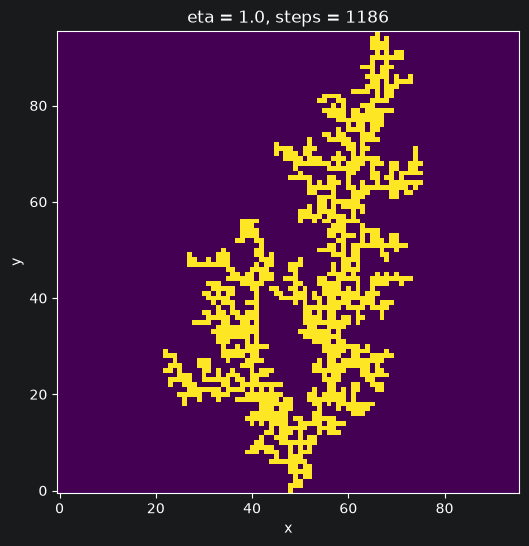

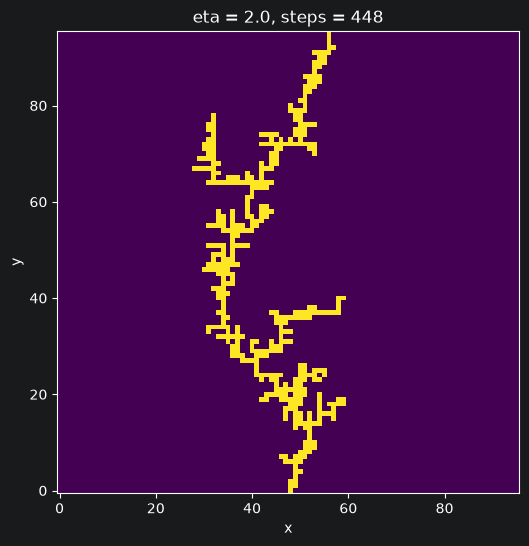

In [5]:
for eta in etas:
    channel = results[eta]["channel"]

    plt.figure(figsize=(6, 6))

    plt.imshow(
        channel,
        origin="lower",
        aspect="equal",
        interpolation="nearest"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"eta = {eta}, "
        f"steps = {results[eta]['steps']}"
    )

    plt.show()